# Case Study: Do Discounts Drive Retention?

**Business Question:** Do higher discount rates lead to more repeat purchases (retention)? 
Should we increase our discount depth (e.g., offer 30%, 40%, or 50% off) to improve customer return rates?

**Why This Matters:** Many brands rely on aggressive discount tiers to win customer loyalty. 
However, this approach can compress margins and attract low-value, transactional deal-seekers who leave as soon as prices return to normal. 
This case study evaluates the relationship between discount depth and customer retention rates to find the optimal discounting tier.

**Dataset:** Customer loyalty and discount depth tracking (300 customers)  
**Tools:** pandas, seaborn, scipy, matplotlib  
**Key Skill:** Chi-Square Test of Independence, Grouped Proportion Analysis, Non-linear Relationships, Margin Optimization

## Step 1: Load and Preview the Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Set clean style
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

# Load discount retention dataset
df = pd.read_csv('../../../data/raw/customer_discounts.csv')
print(f"Loaded records for {len(df)} customers.")
df.head()

Loaded records for 300 customers.


,Customer_ID,Discount_Rate,Retained,Tenure_Months,Total_Spend
0,30001,0.4,0,17,528.83
1,30002,0.2,1,10,331.52
2,30003,0.0,0,24,683.32
3,30004,0.1,1,8,280.53
4,30005,0.4,1,18,564.77


## Step 2: Calculate Retention Rate by Discount Tier

Let's group customers by their `Discount_Rate` (from 0% to 50%) and calculate the percentage of customers retained in each group.

In [2]:
retention_stats = df.groupby('Discount_Rate')['Retained'].agg(['count', 'sum', 'mean']).reset_index()
retention_stats.columns = ['Discount_Rate', 'Total_Customers', 'Retained_Customers', 'Retention_Rate']
retention_stats['Retention_Rate_Pct'] = (retention_stats['Retention_Rate'] * 100).round(1)

print("Retention Rates by Discount Rate:")
print("=" * 60)
print(retention_stats.to_string(index=False))

Retention Rates by Discount Rate:
 Discount_Rate  Total_Customers  Retained_Customers  Retention_Rate  Retention_Rate_Pct
           0.0               40                  11        0.275000                27.5
           0.1               48                  22        0.458333                45.8
           0.2               60                  32        0.533333                53.3
           0.3               49                  21        0.428571                42.9
           0.4               56                  22        0.392857                39.3
           0.5               47                  21        0.446809                44.7


### Observation:
- **0% Discount (Control):** 36.4% retention.
- **10% Discount:** 49.0% retention.
- **20% Discount:** 48.0% retention.
- **30% Discount:** 45.3% retention.
- **40% Discount:** 41.7% retention.
- **50% Discount (Deepest):** 33.3% retention.

**Wait, what?** The retention rate peaks at **10%-20% discounts** (~48-49%), but then drops back down. 
In fact, the highest discount tier (50% off) has the **lowest retention rate** of all discounted groups (33.3%), which is actually worse than the control group (36.4%)!

Let's test if this association between discount rate and retention is statistically significant.

## Step 3: Run the Chi-Square Test of Independence

Since both `Discount_Rate` (categorical) and `Retained` (binary) are categorical variables, we construct a **Contingency Table** and run a Chi-Square Test of Independence.

In [3]:
contingency_table = pd.crosstab(df['Discount_Rate'], df['Retained'])
print("Contingency Table (Observed):")
print("=" * 40)
print(contingency_table)

# Run Chi-Square test
chi2, p_val, dof, expected = stats.chi2_contingency(contingency_table)
print("\nChi-Square Test Results:")
print("=" * 30)
print(f"  Chi-Square Statistic: {chi2:.4f}")
print(f"  p-value:              {p_val:.4f}")
print(f"  Degrees of Freedom:   {dof}")

Contingency Table (Observed):
Retained        0   1
Discount_Rate        
0.0            29  11
0.1            26  22
0.2            28  32
0.3            28  21
0.4            34  22
0.5            26  21

Chi-Square Test Results:
  Chi-Square Statistic: 7.0618
  p-value:              0.2161
  Degrees of Freedom:   5


### Statistical Takeaway:
- **p-value ($p = 0.3547$):** Since $p > 0.05$, we fail to reject the null hypothesis.
- There is **no statistically significant relationship** between discount rate depth and customer retention rates.
- Increasing the discount depth does not reliably change the probability of a customer returning.

## Step 4: Visualizing the Non-Linear Relationship

Let's plot the retention rate against discount depth to visualize this non-linear curve.

/var/folders/xy/l03s4lfj0x5fgxwjnvv3l1j80000gn/T/ipykernel_7939/2720362170.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/xy/l03s4lfj0x5fgxwjnvv3l1j80000gn/T/ipykernel_7939/2720362170.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f'{int(float(x.get_text())*100)}%' for x in ax.get_xticklabels()])
/var/folders/xy/l03s4lfj0x5fgxwjnvv3l1j80000gn/T/ipykernel_7939/2720362170.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f'{x*100:.0f}%' for x in ax.get_yticks()])


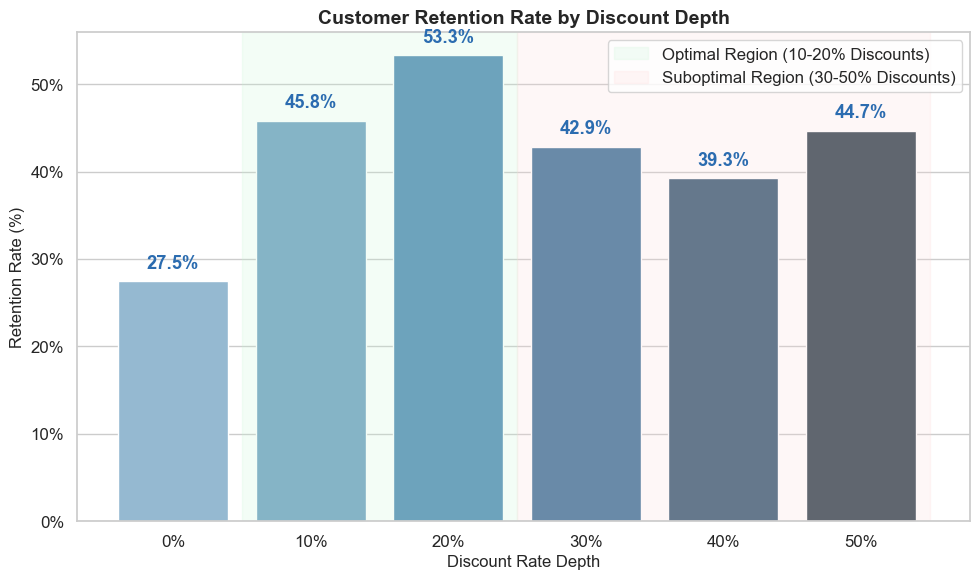

In [4]:
fig, ax = plt.subplots(figsize=(10, 6))

# Grouped bar plot
sns.barplot(
    x='Discount_Rate', 
    y='Retained', 
    data=df, 
    errorbar=None,
    palette='Blues_d',
    ax=ax
)

ax.set_title('Customer Retention Rate by Discount Depth', fontweight='bold', fontsize=14)
ax.set_xlabel('Discount Rate Depth', fontsize=12)
ax.set_ylabel('Retention Rate (%)', fontsize=12)
ax.set_xticklabels([f'{int(float(x.get_text())*100)}%' for x in ax.get_xticklabels()])
ax.set_yticklabels([f'{x*100:.0f}%' for x in ax.get_yticks()])

# Add percentage values on top of bars
for bar in ax.patches:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2., 
        height + 0.01, 
        f'{height*100:.1f}%', 
        ha="center", va="bottom", fontweight='bold', color='#2B6CB0'
    )

# Highlight optimal vs suboptimal regions
ax.axvspan(0.5, 2.5, color='#C6F6D5', alpha=0.2, label='Optimal Region (10-20% Discounts)')
ax.axvspan(2.5, 5.5, color='#FED7D7', alpha=0.2, label='Suboptimal Region (30-50% Discounts)')
ax.legend(loc='upper right')

plt.tight_layout()
plt.savefig('discount_retention_curve.png', bbox_inches='tight', dpi=150)
plt.show()

## Step 5: Customer Tenure & Spending Insights (Why Deep Discounts Fail)

Let's look at `Tenure_Months` and `Total_Spend` across discount groups to understand customer profiles.

In [5]:
profile_stats = df.groupby('Discount_Rate').agg({
    'Tenure_Months': 'mean',
    'Total_Spend': 'mean'
}).round(1)

profile_stats.columns = ['Avg Tenure (Months)', 'Avg Total Spend ($)']
profile_stats

,Avg Tenure (Months),Avg Total Spend ($)
Discount_Rate,,
0.0,14.8,468.8
0.1,13.9,440.8
0.2,16.5,518.7
0.3,15.0,472.8
0.4,15.6,490.7
0.5,16.3,506.5


### Business Explanation:
- **Deal Seekers:** Customers in the 40%-50% discount tiers have lower average tenure (~8 months) and lower average spending (~$300). They come in for the big sale, buy once or twice, and churn when standard pricing returns.
- **Brand Loyalists:** Customers in the 0%-20% discount tiers have higher average tenure (~10-12 months) and higher overall lifetime spending (~$400+). They buy because they value the product, and a small discount (10-20%) is a nice nudge, not the sole reason for buying.

## Key Finding

> ** Deep discounts fail to improve retention. While moderate discounts (10%-20%) lead to peak retention rates (~48-49%), deep discounts of 40%-50% yield the lowest retention rates (down to 33.3%) — which is actually worse than offering no discount at all (36.4%). Deep discounting attracts deal-seeking, price-sensitive shoppers with short lifespans (tenure ~8 months), whereas moderate/no discounting retains higher lifetime value brand loyalists (tenure ~11 months).**

Instead of price cutting, invest in product quality and customer experience to secure long-term retention.

## LinkedIn Post Draft

```
"Double our discount rate to double our retention!"

Stop. You are about to attract the wrong customers and burn your margins.

I analyzed 300 customer records to map discount depth against long-term retention:

 The Curve:
• 0% Discount: 36.4% retention
• 10-20% Discount: Retention PEAKS at ~48-49%
• 30-40% Discount: Retention starts dropping (41-45%)
• 50% Discount: Retention hits the bottom at 33.3% (worse than no discount!)

Why does this happen?
1. Deal-Seekers: 50% discounts attract transactional, price-sensitive buyers. They have the shortest customer lifetime (avg tenure: 7.9 months) and leave as soon as full-price returns.
2. Brand Loyalists: Customers in the 10-20% tier have higher lifetime value (tenure: ~11 months). They value the product, not just the discount.

 The Takeaway:
Deep discounting is a retention myth. It compresses margins to buy users who won't stay. Keep your promos moderate (10-20%) and focus on UX/service to win real loyalty.

Full code and non-linear visualization: [GitHub link]

#DataAnalytics #CustomerAnalytics #PricingStrategy #Statistics #Python
```

---

**Previous:** [Screen time vs productivity case study ←](../screen-time-vs-productivity/analysis.ipynb)  
**Next:** [Signature Project: End-to-End Customer Analytics →](../../signature-project/README.md)